## **Reinforcement Learning Programming-Assignment 1**

#### **Student name**:Chao-Chung ,Liu
#### **Student ID**: 9067679
#### Link : https://github.com/caatat741213/CSCN8020_Assignment1.git
---

#### Logger

In [50]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append('.')

from src.utils import setup_logger, log_section
logger = setup_logger("Assignment1_Complete.log")
log_section(logger, "Reinforcement Learning Programming-Assignment 1", is_main_title=True)


2026-06-12 03:28:57,752 - INFO - ==================================================
2026-06-12 03:28:57,753 - INFO -  Reinforcement Learning Programming-Assignment 1  
2026-06-12 03:28:57,753 - INFO - ==================================================
2026-06-12 03:28:57,754 - INFO - --------------------------------------------------


### Problem 1 [10]
* **Pick-and-Place Robot**: Consider using reinforcement learning to control the motion of a robot arm in a repetitive pick-and-place task. If we want to learn movements that are fast and smooth, the learning agent will have to control the motors directly and obtain feedback about the current positions and velocities of the mechanical linkages. Design the reinforcement learning problem as an MDP, define states, actions, rewards with reasoning.

###  🌞 Answer 1

**Agent**:
The robotic arm controller that decides motor actions.

**Environment**:
The robotic arm, object, target location, and workspace.

The agent interacts with the environment by observing states, taking actions, and receiving rewards.

MDP =(S,A,P,R,γ)

| Element | Meaning                |
| ------- | ---------------------- |
| S       | State                  |
| A       | Action                 |
| P       | Transition Probability |
| R       | Reward                 |
| γ       | Discount Factor        |

---

* **Robot Arm: Pick Object -> Move Object -> Place Object**

* **State** :
    * The robotic arm has **two** joints
    * **Joint Position** : Joint1 = 30°,Joint2 = 45°... 
    * **Joint Velocity** : Joint1 speed = 0.5 rad/s, Joint2 speed = 0.4 rad/s ...
    * **Gripper Status** : Open, Closed
    * **Object position** : x,y
    * **Goal position**  : x,y

    S=(θ1​,θ2​,v1​,v2​,g,xobj,yobj,xgoal,ygoal)

    * θ = joint position, θ1, θ2 $\in [0, 2\pi]$
    * v = joint velocity, v1, v2 $\in [-v_{max}, v_{max}]$
    * g = gripper state, g $\in \{0, 1\}$ ,0:Open,1:Closed
    * xobj,yobj = Object position
    * xgoal,ygoal = Goal position

* **Action** :

    Actions directly control the robot motors.Examples include:
    * Increase joint velocity
    * Decrease joint velocity
    * Keep joint velocity
    * Open gripper
    * Close gripper
    * Keep gripper

    $A = \{a_1, a_2, a_g\}$

    * $a_1, a_2 \in \{-1, 0, 1\}$ , -1:speed down , 0:Keep , 1:speed up 
    * $a_g \in \{Open, Keep, Close\}$


* **Transition Probability** :

    $P(s_{t+1} | s_t, a_t)$ , For simplicity, the transition model is assumed to be deterministic.The current state $s_t$ and action $a_t$, the next state $s_{t+1}$ is uniquely determined ,is computed as follows:

    1. Velocity Update: $v_{i, t+1} = v_{i, t} + a_{i, t}$
    2. Position Update: $\theta_{i, t+1} = \theta_{i, t} + v_{i, t+1} \cdot \Delta t$
    3. Gripper State: $g_{t+1}=f(g_t,a_g)$,
        - If $a_g$ = Open  → g=0;
        - If $a_g$ = Close → g=1
        - If $a_g$ = Keep  → g=$g_t$

* **Reward**

    we want to learn movements that are successful,fast and smooth.

    $R(s, a, s') = R_{\text{task}} + R_{\text{time}} + R_{\text{smooth}} + R_{\text{safety}}$

    | Component | Value                     | Purpose |
    | ----------| ------------------------- | ------ |
    | $R_{\text{task}}$ | +100 if success, else 0 | Successfully place object |
    | $R_{\text{time}}$ | -1 per time step | Each time step   |
    | $R_{\text{smooth}}$ | $-5 \sum_{i=1}^2 (\Delta v_i)^2$            | Penalize jerky movements     |
    | $R_{\text{safety}}$ | -20 if collisiont            | Discourage unsafe actions     |

    * Terminal State : An episode terminates when:
        - the object is successfully placed at the goal location
        - a collision occurs

* **Discount Factor**  :
    * γ = 0.99
    * I choose a high discount factor (γ = 0.99) because I want the robot to prioritize reaching the target and successfully completing the task. By doing so, the agent learns to favor the long-term +100 reward rather than trying to minimize the cumulative -1 time penalties by idling or moving aimlessly.



### 🔮Talking Point(Problem 1)

**Talking Point A : Key Reinforcement Learning Feature**

* We represent the robot arm's `joint positions`, `velocities`, `gripper status`, `object position`, and `goal position` as the State $s$ and motor controls as the Action $A$. By defining the transition probability $P(s'|s,a)$ and a reward $R$, we transform a machinery control task into that the agent can solve using RL algorithms.

**Talking Point B : Implementation and Testing Challenge**
* A major challenge is reward shaping.We need to balance the +100 goal reward with the -5 penalty for jerky movements ($R_{\text{smooth}}$). If the smoothness penalty is too high, the robot may move too slowly; if it is too low, the robot may shake during movement.

**Talking Point C : Why This Is Reinforcement Learning**
* Because the robot learns by **Trial and Error** through the agent-environment loop, not by learning from labeled datasets (like in Supervised Learning).Mapping to Sutton & Barto (2018): Our implementation follows the Agent-Environment Interaction cycle described in Chapter 3. The agent observes state $S_t$, takes action $A_t$, and receives a reward $R_{t+1}$ and next state $S_{t+1}$. It uses the Bellman Equation (Section 3.5) to iteratively update its value function.

### Code:

In [51]:
from src.environments import PickAndPlaceEnvironment

log_section(logger, "Problem 1: Pick-and-Place Robot")

#robot_env_default = PickAndPlaceEnvironment(logger=logger)

robot_env_custom = PickAndPlaceEnvironment(
    logger=logger, 
    gamma=0.99,                  # γ
    reward_task=100.0,          # Success reward
    reward_time=-1.0,           # Time penalty
    reward_collision=-20.0,     # Collision penalty
    penalty_smooth=-10.0        # Smoothness penalty
)

# a{a1, a2, ag} a1, a2 ∈ {-1, 0, 1} ,ag ∈ {'open', 'keep', 'close'}.
sample_action = (1, -1, 'keep')
sample_reward = robot_env_custom.dummy_step(action=sample_action)

logger.info(f"Problem 1 completed. Sample Reward: {sample_reward}\n")


2026-06-12 03:28:57,952 - INFO - ==================================================
2026-06-12 03:28:57,953 - INFO -          Problem 1: Pick-and-Place Robot          
2026-06-12 03:28:57,953 - INFO - ==================================================
2026-06-12 03:28:57,954 - INFO - PickAndPlaceEnvironment Initialized.
2026-06-12 03:28:57,954 - INFO - Parameters: Gamma=0.99, R_task=100.0, R_time=-1.0
2026-06-12 03:28:57,954 - INFO - Total actions available: 27
2026-06-12 03:28:57,955 - INFO - Action Taken: dv1=1, dv2=-1, gripper=keep | Reward: -21.0
2026-06-12 03:28:57,955 - INFO - Problem 1 completed. Sample Reward: -21.0



---

### Problem 2 [20]
**Problem Statement**

**2x2 Gridworld**: Consider a 2x2 gridworld with the following characteristics:
* State Space (S): s1, s2, s3, s4.
* Action Space (A): up, down, left, right.
* Initial Policy (π): For all states, π(up|s) = 1.
* Transition Probabilities P(s′|s, a):
    * If the action is valid (does not run into a wall), the transition is deterministic.
    * Otherwise, s′ = s.
* Rewards R(s):
    * R(s1) = 5 for all actions a.
    * R(s2) = 10 for all actions a.
    * R(s3) = 1 for all actions a.
    * R(s4) = 2 for all actions a.

![Figure1-2x2 Gridworld](images/Figure1-2x2Gridworld.png)

**Tasks**

Perform two iterations of Value Iteration for this gridworld environment. Show the step-by-step process(without code) including policy evaluation and policy improvement. Provide the following for each iteration:
* Iteration 1:
    1. Show the initial value function (V) for each state.
    2. Perform value function updates.
    3. Show the updated value function.
* Iteration 2: Show the value function (V) after the second iteration.

###  🌞 Answer 2

**Grid Layout**
```
| s1(R=5) | s2(R=10)|
| s3(R=1) | s4(R=2) |
```
* Actions are **up**, **down**, **left**, and **right**. Invalid actions keep the agent in the **same state**.

- **States**:$S$: $\{s_1, s_2, s_3, s_4\}$
- **Actions**:$A$: $\{up, down, left, right\}$
- **Initial policy**: $\pi_0$: $\pi(\text{up} \mid s) = 1$ for all $s$
- **Rewards**:$R(s)$: $R(s_1)=5, R(s_2)=10, R(s_3)=1, R(s_4)=2$
- **Discount factor**:$\gamma$ : 0.9(assumed)
- **Value Iteration**: $$V_{k+1}(s) \leftarrow \max_{a} \sum_{s', r} p(s', r | s, a) [r + \gamma V_k(s')]$$
- **Pseudocode**:
    ```
    Input: MDP(S, A, P, R, γ), threshold θ
    Initialise V(s) = 0 for all s ∈ S+
    Loop:
        Δ ← 0
        For each s ∈ S:
            v ← V(s)
            V(s) ← max_a [ R(s) + γ Σ_{s'} P(s'|s,a) V(s') ]
            Δ ← max(Δ, |v − V(s)|)
    Until Δ < θ(a small positive number)
    Output: π*(s) = argmax_a [ R(s) + γ Σ_{s'} P(s'|s,a) V(s') ]
    ```

* **Initialization**
    - $V_0(s_1) = V_0(s_2) = V_0(s_3) = V_0(s_4) = 0$

* **First Iteration ($k=1$)**
    * Because the initial value is 0.
    - $V_1(s_1) = \max_a [R(s_1, a) + 0.9 \cdot V_0(s')] = 5 + 0 = 5$
    - $V_1(s_2) = \max_a [R(s_2, a) + 0.9 \cdot V_0(s')] = 10 + 0 = 10$
    - $V_1(s_3) = \max_a [R(s_3, a) + 0.9 \cdot V_0(s')] = 1 + 0 = 1$
    - $V_1(s_4) = \max_a [R(s_4, a) + 0.9 \cdot V_0(s')] = 2 + 0 = 2$

    so:
    * $\gamma = 0.9$，$R(s_1)=5, R(s_2)=10, R(s_3)=1, R(s_4)=2$
    * ($k=1$): $V_1(s_1)=5, V_1(s_2)=10, V_1(s_3)=1, V_1(s_4)=2$

```
| 5 | 10|
| 1 | 2 |
```

* **Second Iteration ($k=2$)**
    * We use the result of $V_1$ to calculate $V_2$
    * $V_2(s) = \max_a [R(s) + 0.9 \cdot V_1(s')]$

    **State s1 ($R=5$):**

    * **Action up (wall)**: $5 + 0.9 \times V_1(s1) = 5 + 0.9 \times 5 = 9.5$
    * **Action down**: $5 + 0.9 \times V_1(s3) = 5 + 0.9 \times 1 = 5.9$
    * **Action left (wall)**: $5 + 0.9 \times V_1(s1) = 5 + 0.9 \times 5 = 9.5$
    * **Action right**: $5 + 0.9 \times V_1(s2) = 5 + 0.9 \times 10 = 14$
    * **result**: $V_2(s1) = \max(9.5,\ 5.9,\ 9.5,\ 14) = 14$ (Best `right`)

    **State s2 ($R=10$):**

    * **Action up (wall)**: $10 + 0.9 \times V_1(s2) = 10 + 0.9 \times 10 = 19$
    * **Action down**: $10 + 0.9 \times V_1(s4) = 10 + 0.9 \times 2 = 11.8$
    * **Action left**: $10 + 0.9 \times V_1(s1) = 10 + 0.9 \times 5 = 14.5$
    * **Action right (wall)**: $10 + 0.9 \times V_1(s2) = 10 + 0.9 \times 10 = 19$
    * **result**: $V_2(s2) = \max(19,\ 11.8,\ 14.5,\ 19) = 19$ (Best `up` or `right`)

    **State s3 ($R=1$):**

    * **Action up**: $1 + 0.9 \times V_1(s1) = 1 + 0.9 \times 5 = 5.5$
    * **Action down (wall)**: $1 + 0.9 \times V_1(s3) = 1 + 0.9 \times 1 = 1.9$
    * **Action left (wall)**: $1 + 0.9 \times V_1(s3) = 1 + 0.9 \times 1 = 1.9$
    * **Action right**: $1 + 0.9 \times V_1(s4) = 1 + 0.9 \times 2 = 2.8$
    * **result**: $V_2(s3) = \max(5.5,\ 1.9,\ 1.9,\ 2.8) = 5.5$ (Best `up`)

    **State s4 ($R=2$):**

    * **Action up**: $2 + 0.9 \times V_1(s2) = 2 + 0.9 \times 10 = 11$
    * **Action down (wall)**: $2 + 0.9 \times V_1(s4) = 2 + 0.9 \times 2 = 3.8$
    * **Action left**: $2 + 0.9 \times V_1(s3) = 2 + 0.9 \times 1 = 2.9$
    * **Action right (wall)**: $2 + 0.9 \times V_1(s4) = 2 + 0.9 \times 2 = 3.8$
    * **result**: $V_2(s4) = \max(11,\ 3.8,\ 2.9,\ 3.8) = 11$ (Best `up`)

    | State | up | down | left | right | **Best action** |
    |-------|----|------|------|-------|----------------|
    | $s_1$ | $V_2(s_1)=9.5$ | $V_2(s_3)=5.9$ | $V_2(s_1)=9.5$ | $V_2(s_2)=\mathbf{14}$ | **right** |
    | $s_2$ | $V_2(s_2)=\mathbf{19}$ | $V_2(s_4)=11.8$ | $V_2(s_1)=14.5$ | $V_2(s_2)=\mathbf{19}$ | **up,right**  |
    | $s_3$ | $V_2(s_1)=\mathbf{5.5}$ | $V_2(s_3)=1.9$ | $V_2(s_3)=1.9$ | $V_2(s_4)=2.8$ | **up** |
    | $s_4$ | $V_2(s_2)=\mathbf{11}$ | $V_2(s_4)=3.8$ | $V_2(s_3)=2.9$ | $V_2(s_4)=3.8$ | **up** |

    SO:
    * ($k=2$): $V_2(s_1)=14, V_1(s_2)=19, V_1(s_3)=5.5, V_1(s_4)=11$

### 🔮Talking Point(Problem 2)

**Talking Point A : Key Reinforcement Learning Feature**

* The key feature here is **Value Iteration**.Instead of doing a long policy evaluation, it combines checking the value and improving the policy into one simple step. It uses the Bellman Optimality Equation. This means the agent updates the value of its current state just by looking at the values of the next states.

**Talking Point B : Implementation and Testing Challenge**
* The main challenge was making sure the code output matched my hand calculations perfectly.When writing the Bellman update, I had to be very careful to create a copy of the old values first (`new_V = np.copy(self.V)`). If I just updated the same array directly, the math would use the new values too early. This would make the final numbers completely different from my manual math on paper.

**Talking Point C : Why This Is Reinforcement Learning**
* This is Reinforcement Learning because the agent learns the best actions by using the environment's rules (transition probabilities and rewards). We update the values using the Bellman equation.

### Code:

In [52]:
from src.environments import GridWorld2x2
from src.agents import ValueIterationAgent

log_section(logger, "Problem 2: 2x2 Gridworld Value Iteration")

# Manual Results
logger.info("【Manual Results】")
logger.info("Expected Iteration 1: V = [ 5.0, 10.0,  1.0,  2.0]")
logger.info("Expected Iteration 2: V = [14.0, 19.0,  5.5, 11.0]")
logger.info("-" * 40)

# Agent Results
logger.info("【Agent Results】")
env_2x2 = GridWorld2x2(logger=logger)
agent_vi = ValueIterationAgent(env=env_2x2, gamma=0.9, logger=logger)

# 2 Iteration
final_values, _ = agent_vi.iterate(num_iterations=2)

logger.info("-" * 40)

# Verification Conclusion
logger.info("Verification Conclusion")
logger.info(f"V(s1) : Agent={final_values[0]:<5} | Manual=14.0")
logger.info(f"V(s2) : Agent={final_values[1]:<5} | Manual=19.0")
logger.info(f"V(s3) : Agent={final_values[2]:<5} | Manual=5.5")
logger.info(f"V(s4) : Agent={final_values[3]:<5} | Manual=11.0")
logger.info("Problem 2 completed.\n")

2026-06-12 03:28:58,163 - INFO - ==================================================
2026-06-12 03:28:58,164 - INFO -      Problem 2: 2x2 Gridworld Value Iteration     
2026-06-12 03:28:58,164 - INFO - ==================================================
2026-06-12 03:28:58,164 - INFO - 【Manual Results】
2026-06-12 03:28:58,165 - INFO - Expected Iteration 1: V = [ 5.0, 10.0,  1.0,  2.0]
2026-06-12 03:28:58,165 - INFO - Expected Iteration 2: V = [14.0, 19.0,  5.5, 11.0]
2026-06-12 03:28:58,165 - INFO - ----------------------------------------
2026-06-12 03:28:58,166 - INFO - 【Agent Results】
2026-06-12 03:28:58,166 - INFO - Iteration 1 Values: [ 5. 10.  1.  2.]
2026-06-12 03:28:58,167 - INFO - Iteration 2 Values: [14.  19.   5.5 11. ]
2026-06-12 03:28:58,168 - INFO - ----------------------------------------
2026-06-12 03:28:58,168 - INFO - Verification Conclusion
2026-06-12 03:28:58,169 - INFO - V(s1) : Agent=14.0  | Manual=14.0
2026-06-12 03:28:58,169 - INFO - V(s2) : Agent=19.0  | Manual=1

---

### Problem 3 [35]

**Problem Statement**

**5x5 Gridworld**: In Lecture 3’s programming exercise (here), we explored an MDP based on a 5x5 gridworld and implemented Value Iteration to estimate the optimal state-value function (V∗) and optimal policy (π∗).

The environment can be described as follows:

![Figure2- 5x5 Gridworld](images/Figure2-5x5Gridworld.png)


* States: states are identified by their row and column, the same as a regular matrix. Ex: the state in row 0 and column 3 is s0,3 (Figure: 2)
    * Terminal/Goal state: The episode ends if the agent reached this state. sGoal = s4,4
    * Grey states: {s2,2, s3,0, s0,4}, these are valid but non-favourable states, as will be seen in the reward function.
* Actions: a1 = right, a2 = down, a3 = down, a4 = up for all states.
* Transitions: If an action is valid, the transition is deterministic, otherwise s′ = s
* Rewards R(s):

**Tasks**

**Task1: Update MDP Code**

1. Update the reward function to be a list of reward based on whether the state is terminal, grey, or a regular state.
2. Run the existing code developed in class and obtain the optimal state-values and optimal policy.Provide a figures of the gridworld with the obtained V∗ and π∗ (You can manually create a table).

**Task 2: Value Iteration Variations**

Implement the following variation of value iteration. Confirm that it reaches the same optimal statevalue function and policy.

1. In-Place Value Iteration: Use a single array to store the state values. This means that you update the value of a state and immediately use that updated value in the subsequent updates.

**Deliverables**

* Full code with comments to explain key steps and calculations.
* Provide the estimated value function for each state.
* Important: Compare the performance of these variations in terms of optimization time, number of episodes, and provide comments on their computational complexity.

###  🌞 Answer 3

**Environment Setup (5x5 Grid)**
* **States**: 25 states, identified by row and column (e.g., $s_{0,3}$). 
* **Terminal State**: $s_{4,4}$ (Goal). Reaching it ends the episode.
* **Grey States**: $s_{2,2}, s_{3,0}, s_{0,4}$. These are valid but give bad rewards.
* **Actions**: Up, Down, Left, Right. Deterministic transitions (hitting a wall returns $s' = s$).
* **Rewards**:
    * Transition to $s_{4,4}$ (Goal): $+10$
    * Transition to Grey states: $-5$
    * Transition to other regular states: $-1$

* **Standard Value Iteration**(4.10)
    - Value iteration is implemented by turning the Bellman optimality equation into an update rule, with the following iterative formula:

    $v_{k+1}(s) \leftarrow \max_{a} \sum_{s', r} p(s', r | s, a) [r + \gamma v_k(s')]$

    - Where $V_k$ represents the value function at the $k$-th iteration, which is updated repeatedly until the value function converges (i.e., $V$ no longer changes significantly).

Pseudocode
```
Algorithm: Value Iteration
Input: The MDP (S, A, P, R, gamma)
Parameter: A small threshold theta > 0 (for convergence check)

Initialize V(s) arbitrarily (e.g., V(s) = 0 for all s in S)

Loop:
    delta <- 0
    For each state s in S:
        v <- V(s)
        V(s) <- max_a sum_{s',r} p(s',r | s,a) * [r + gamma * V(s')]
        delta <- max(delta, |v - V(s)|)
until delta < theta

Output: A deterministic policy, pi, such that:
    pi(s) = argmax_a sum_{s',r} p(s',r | s,a) * [r + gamma * V(s')]
```

* **In-Place Value Iteration**
    - The "In-Place" version refers to updating the value function array directly during the calculation process, without waiting for a full sweep to complete. The core formula is the same as standard value iteration, but it updates the values directly:

    $V(s) \leftarrow \max_{a} \sum_{s', r} p(s', r | s, a) [r + \gamma V(s')]$

    - In the In-Place version, once a state $V(s')$ is updated, subsequent calculations for neighboring states use this newly updated $V(s')$ immediately. This typically results in faster convergence compared to standard synchronous updates.

Pseudocode
```
Algorithm: In-Place Value Iteration
Input: The MDP (S, A, P, R, gamma)
Parameter: A small threshold theta > 0

Initialize V(s) = 0 for all s in S

Loop:
    delta <- 0
    For each state s in S:
        old_v <- V(s)
        V(s) <- max_a sum_{s',r} p(s',r | s,a) * [r + gamma * V(s')]
        delta <- max(delta, |old_v - V(s)|)
until delta < theta

```

### Code:

#### Task 1 (Standard Value Iteration)

In [53]:
import time
import numpy as np
from src.environments import GridWorld5x5
from src.agents import ValueIterationAgent

log_section(logger, "Problem 3, Task 1: Standard Value Iteration")

# 5x5 Gridworld Environment
env_5x5 = GridWorld5x5(logger=logger)

# Standard Agent
agent_standard = ValueIterationAgent(env=env_5x5, gamma=0.9, logger=None)

# time
start_time_std = time.perf_counter()
v_standard, iter_standard = agent_standard.iterate()
time_standard = time.perf_counter() - start_time_std

logger.info(f"Task 1 Completed: {iter_standard} iterations.")

# Optimal Policy ( V* 和 π*)
policy_standard = []
action_symbols = ['↑', '→', '↓', '←']
for s in range(25):
    if s == 24: # Goal state
        policy_standard.append('G')
        continue
    action_values = []
    for a in range(4):
        prob, next_s, reward, terminated = env_5x5.P[s][a][0]
        val = reward if terminated else reward + 0.9 * v_standard[next_s]
        action_values.append(val)
    best_a = np.argmax(action_values)
    policy_standard.append(action_symbols[best_a])

# V* 
logger.info("-" * 40)
logger.info("【Optimal Value Function V* (Standard VI)】")
v_grid_std = np.round(np.array(v_standard).reshape(5, 5), 2)
for row in v_grid_std:
    row_str = " | ".join([f"{val:>6.2f}" for val in row])
    logger.info(f"| {row_str} |")

#  π* 
logger.info("-" * 40)
logger.info("【Optimal Policy π* (Standard VI)】")
p_grid_std = np.array(policy_standard).reshape(5, 5)
for row in p_grid_std:
    row_str = " | ".join([f"{val:>2}" for val in row])
    logger.info(f"| {row_str} |")

2026-06-12 03:28:58,363 - INFO - ==================================================
2026-06-12 03:28:58,364 - INFO -    Problem 3, Task 1: Standard Value Iteration    
2026-06-12 03:28:58,364 - INFO - ==================================================
2026-06-12 03:28:58,365 - INFO - GridWorld5x5 Initialized.
2026-06-12 03:28:58,366 - INFO - Task 1 Completed: 9 iterations.
2026-06-12 03:28:58,366 - INFO - ----------------------------------------
2026-06-12 03:28:58,367 - INFO - 【Optimal Value Function V* (Standard VI)】
2026-06-12 03:28:58,368 - INFO - |  -0.43 |   0.63 |   1.81 |   3.12 |   4.58 |
2026-06-12 03:28:58,368 - INFO - |   0.63 |   1.81 |   3.12 |   4.58 |   6.20 |
2026-06-12 03:28:58,369 - INFO - |   1.81 |   3.12 |   4.58 |   6.20 |   8.00 |
2026-06-12 03:28:58,369 - INFO - |   3.12 |   4.58 |   6.20 |   8.00 |  10.00 |
2026-06-12 03:28:58,369 - INFO - |   4.58 |   6.20 |   8.00 |  10.00 |   0.00 |
2026-06-12 03:28:58,370 - INFO - ----------------------------------------
2

#### Task 2 (In-Place Value Iteration)

In [54]:
from src.agents import InPlaceValueIterationAgent

log_section(logger, "Problem 3, Task 2: In-Place Value Iteration")

#  In-Place Agent Agent
agent_inplace = InPlaceValueIterationAgent(env=env_5x5, gamma=0.9, logger=None)

# time
start_time_in = time.perf_counter()
v_inplace, iter_inplace = agent_inplace.iterate()
time_inplace = time.perf_counter() - start_time_in

logger.info(f"Task 2 Completed: {iter_inplace} iterations.")

#  Optimal Policy 
policy_inplace = []
for s in range(25):
    if s == 24: # Goal state
        policy_inplace.append('G')
        continue
    action_values = []
    for a in range(4):
        prob, next_s, reward, terminated = env_5x5.P[s][a][0]
        val = reward if terminated else reward + 0.9 * v_inplace[next_s]
        action_values.append(val)
    best_a = np.argmax(action_values)
    policy_inplace.append(action_symbols[best_a])

#  V* 
logger.info("-" * 40)
logger.info("【Optimal Value Function V* (In-Place VI)】")
v_grid_in = np.round(np.array(v_inplace).reshape(5, 5), 2)
for row in v_grid_in:
    row_str = " | ".join([f"{val:>6.2f}" for val in row])
    logger.info(f"| {row_str} |")

#  π* 
logger.info("-" * 40)
logger.info("【Optimal Policy π* (In-Place VI)】")
p_grid_in = np.array(policy_inplace).reshape(5, 5)
for row in p_grid_in:
    row_str = " | ".join([f"{val:>2}" for val in row])
    logger.info(f"| {row_str} |")

# comparison
difference = np.max(np.abs(v_standard - v_inplace))
logger.info("-" * 40)
if difference < 1e-4:
    logger.info("Validation: In-Place VI reached the EXACT SAME optimal state-values as Standard VI.")
else:
    logger.info("Validation Failed: The values are different.")

2026-06-12 03:28:58,567 - INFO - ==================================================
2026-06-12 03:28:58,568 - INFO -    Problem 3, Task 2: In-Place Value Iteration    
2026-06-12 03:28:58,568 - INFO - ==================================================
2026-06-12 03:28:58,569 - INFO - Task 2 Completed: 9 iterations.
2026-06-12 03:28:58,570 - INFO - ----------------------------------------
2026-06-12 03:28:58,570 - INFO - 【Optimal Value Function V* (In-Place VI)】
2026-06-12 03:28:58,571 - INFO - |  -0.43 |   0.63 |   1.81 |   3.12 |   4.58 |
2026-06-12 03:28:58,571 - INFO - |   0.63 |   1.81 |   3.12 |   4.58 |   6.20 |
2026-06-12 03:28:58,572 - INFO - |   1.81 |   3.12 |   4.58 |   6.20 |   8.00 |
2026-06-12 03:28:58,572 - INFO - |   3.12 |   4.58 |   6.20 |   8.00 |  10.00 |
2026-06-12 03:28:58,572 - INFO - |   4.58 |   6.20 |   8.00 |  10.00 |   0.00 |
2026-06-12 03:28:58,572 - INFO - ----------------------------------------
2026-06-12 03:28:58,573 - INFO - 【Optimal Policy π* (In-Plac

#### Comparison & Complexity

In [55]:
log_section(logger, "Problem 3: Performance Comparison")

logger.info("【Execution Metrics】")
logger.info(f"1. Standard Value Iteration: {iter_standard} iterations | Time: {time_standard:.5f} sec")
logger.info(f"2. In-Place Value Iteration: {iter_inplace} iterations | Time: {time_inplace:.5f} sec")
logger.info("-" * 40)

logger.info("【Computational Complexity Comments】")
logger.info(
    "Space Complexity: "
    "Standard VI requires O(2|S|) space because it maintains two separate arrays (old V and new V). "
    "In-Place VI requires only O(|S|) space because it updates the single value array directly."
)
logger.info(
    "Time Complexity: "
    "Both algorithms have a per-iteration complexity of O(|S| * |A|). "
    "However, In-Place VI typically requires fewer total episodes (iterations) to converge "
    "because it immediately uses updated state values for subsequent calculations within the same sweep, "
    "leading to faster information propagation across the grid."
)

logger.info("Problem 3 fully completed.\n")

2026-06-12 03:28:58,775 - INFO - ==================================================
2026-06-12 03:28:58,775 - INFO -         Problem 3: Performance Comparison         
2026-06-12 03:28:58,776 - INFO - ==================================================
2026-06-12 03:28:58,776 - INFO - 【Execution Metrics】
2026-06-12 03:28:58,777 - INFO - 1. Standard Value Iteration: 9 iterations | Time: 0.00031 sec
2026-06-12 03:28:58,777 - INFO - 2. In-Place Value Iteration: 9 iterations | Time: 0.00032 sec
2026-06-12 03:28:58,777 - INFO - ----------------------------------------
2026-06-12 03:28:58,778 - INFO - 【Computational Complexity Comments】
2026-06-12 03:28:58,778 - INFO - Space Complexity: Standard VI requires O(2|S|) space because it maintains two separate arrays (old V and new V). In-Place VI requires only O(|S|) space because it updates the single value array directly.
2026-06-12 03:28:58,778 - INFO - Time Complexity: Both algorithms have a per-iteration complexity of O(|S| * |A|). However, I

### 🔮Talking Point(Problem 3)

**Talking Point A : Key Reinforcement Learning Feature**
* This problem introduces **In-Place Value Iteration**. In standard Value Iteration, we use two separate arrays (one for old values, one for new values). In the In-Place version, we use only one single array. When a state's value is updated, the new value is immediately used to calculate the next states in the same loop. This makes the algorithm converge (finish) faster.

**Talking Point B : Implementation and Testing Challenge**
* Measuring the optimization time was tricky because both algorithms run very fast. I had to use Python's `time.perf_counter()` carefully to capture the small time difference between the standard and in-place methods.

**Talking Point C : Why This Is Reinforcement Learning**
* For **Standard Value Iteration**,my code uses `new_V = np.copy(self.V)`. This matches the **math equation (4.10)** on page 83. It only uses old values to calculate new ones.
* For **In-Place Value Iteration**, my code updates `self.V[s]` directly without copying. This perfectly matches the pseudocode in **Figure 4.5 (page 83)**. It uses a single array to make the algorithm run faster.

---

### Problem 4 [35]

**Problem Statement**

**Off-policy Monte Carlo with Importance Sampling**: We will use the same environment, states,actions, and rewards in Problem 3.

**Task**

Implement the off-policy Monte Carlo with Importance sampling algorithm to estimate the value function for the given gridworld. Use a fixed behavior policy b(a|s) (e.g., a random policy) to generate episodes and a greedy target policy.

**Suggested steps**

1. Generate multiple episodes using the behavior policy b(a|s).
2. For each episode, calculate the returns (sum of discounted rewards) for each state.
3. Use importance sampling to estimate the value function and update the target policy π(a|s).
4. You can assume a specific discount factor (e.g., γ = 0.9) for this problem.
5. Use the same main algorithm implemented in lecture 4 in class.

**Deliverables**

* Full code with comments to explain key steps and calculations.
* Provide the estimated value function for each state.
* Important Compare the estimated value function obtained from Monte Carlo with the one
obtained from Value Iteration in terms of optimization time, number of episodes, computational complexity, and any other aspects you notice.

###  🌞 Answer 4

**Environment Setup**
* We use the exact same 5x5 Gridworld from Problem 3.
* **Discount factor ($\gamma$)**: 0.9.

**Algorithm Setup**
* **Behavior Policy ($\mu$)**: A random policy used to explore the environment and generate episodes. It picks any of the 4 actions with a 25% chance ($0.25$).
* **Target Policy ($\pi$)**: A greedy policy that we want to optimize. It always picks the best action based on the current $Q$-values.
* **Importance Sampling**: Because we learn the target policy $\pi$ using data generated by a different behavior policy $\mu$, we must correct the difference using the Importance Sampling ratio ($\rho$). We will use Weighted Importance Sampling.

#### Importance Sampling Formulae
* In off-policy learning, we use experience generated by a behavior policy ($\mu$) to estimate the value function of a target policy ($\pi$).
    * **Importance-sampling ratio** : For a trajectory from time $t$ to $T$, the importance-sampling ratio is defined as(P128 E5.3):

    $$\rho_{t:T-1} = \prod_{k=t}^{T-1} \frac{\pi(A_k|S_k)}{\mu(A_k|S_k)}$$

    * **Value Estimation Formulae**:
        - **Ordinary Importance Sampling**:

        $$V(s) = \frac{\sum_{t \in \mathcal{T}(s)} \rho_{t:T(t)-1} G_t}{|\mathcal{T}(s)|}$$

        - **Weighted Importance Sampling**:

        $$V(s) = \frac{\sum_{t \in \mathcal{T}(s)} \rho_{t:T(t)-1} G_t}{\sum_{t \in \mathcal{T}(s)} \rho_{t:T(t)-1}}$$

Pseudocode

```

Algorithm: Off-policy MC control (using weighted importance sampling)

Initialize, for all s in S, a in A(s):
    Q(s, a) <- arbitrary
    C(s, a) <- 0
    pi(s) <- greedy action with respect to Q

Repeat forever:
    Generate an episode using any soft behavior policy mu: S0, A0, R1, ..., ST-1, AT-1, RT, ST
    G <- 0
    W <- 1
    For t = T-1 downto 0:
        G <- gamma * G + Rt+1
        C(St, At) <- C(St, At) + W
        Q(St, At) <- Q(St, At) + (W / C(St, At)) * [G - Q(St, At)]
        pi(St) <- argmax_a Q(St, a)
        
        W <- W * (pi(At|St) / mu(At|St))
        If W == 0:
            Exit ForLoop
            
```

### Code:

In [56]:
import time
import numpy as np
from src.environments import GridWorld5x5
from src.agents import OffPolicyMCAgent

log_section(logger, "Problem 4: Off-Policy Monte Carlo")

# MC Agent
env_mc = GridWorld5x5(logger=logger)
agent_mc = OffPolicyMCAgent(env=env_mc, gamma=0.9, logger=logger)

# time
num_episodes = 10000
start_time_mc = time.perf_counter()
v_mc, policy_mc = agent_mc.train(num_episodes=num_episodes)
time_mc = time.perf_counter() - start_time_mc

logger.info(f"MC Training Completed in {time_mc:.5f} sec for {num_episodes} episodes.")

# print MC's V* and π*
logger.info("-" * 40)
logger.info("【Estimated Value Function V* (Monte Carlo)】")
v_grid_mc = np.round(v_mc.reshape(5, 5), 2)
for row in v_grid_mc:
    row_str = " | ".join([f"{val:>6.2f}" for val in row])
    logger.info(f"| {row_str} |")

logger.info("-" * 40)
logger.info("【Estimated Policy π* (Monte Carlo)】")
action_symbols = ['↑', '→', '↓', '←']
p_grid_mc = [action_symbols[a] if i != 24 else 'G' for i, a in enumerate(policy_mc)]
p_grid_mc = np.array(p_grid_mc).reshape(5, 5)
for row in p_grid_mc:
    row_str = " | ".join([f"{val:>2}" for val in row])
    logger.info(f"| {row_str} |")

2026-06-12 03:28:58,975 - INFO - ==================================================
2026-06-12 03:28:58,976 - INFO -         Problem 4: Off-Policy Monte Carlo         
2026-06-12 03:28:58,976 - INFO - ==================================================
2026-06-12 03:28:58,977 - INFO - GridWorld5x5 Initialized.
2026-06-12 03:28:58,977 - INFO - Starting Off-Policy MC training for 10000 episodes...
2026-06-12 03:29:02,809 - INFO - MC Training Completed in 3.83193 sec for 10000 episodes.
2026-06-12 03:29:02,810 - INFO - ----------------------------------------
2026-06-12 03:29:02,811 - INFO - 【Estimated Value Function V* (Monte Carlo)】
2026-06-12 03:29:02,811 - INFO - |  -0.44 |   0.56 |   1.77 |   3.07 |   4.15 |
2026-06-12 03:29:02,812 - INFO - |   0.62 |   1.77 |   3.01 |   4.48 |   6.00 |
2026-06-12 03:29:02,812 - INFO - |   1.74 |   3.05 |   4.50 |   6.13 |   7.94 |
2026-06-12 03:29:02,812 - INFO - |   3.03 |   4.50 |   6.11 |   7.94 |  10.00 |
2026-06-12 03:29:02,812 - INFO - |   4.43

2026-06-12 03:29:03,017 - INFO - ==================================================
2026-06-12 03:29:03,018 - INFO -     Problem 4: Advanced Comparison (MC vs VI)     
2026-06-12 03:29:03,019 - INFO - ==================================================
2026-06-12 03:29:03,019 - INFO - ==================================================================
2026-06-12 03:29:03,020 - INFO -   Off-Policy MC  vs  Standard Value Iteration
2026-06-12 03:29:03,020 - INFO - ==================================================================
2026-06-12 03:29:03,020 - INFO -   Metric                                      MC              VI
2026-06-12 03:29:03,021 - INFO -   ------------------------------------------------------------
2026-06-12 03:29:03,021 - INFO -   Episodes / Iterations                   10,000               9
2026-06-12 03:29:03,022 - INFO -   Wall-clock time (s)                    3.83193         0.00031
2026-06-12 03:29:03,022 - INFO -   Needs env model?                            

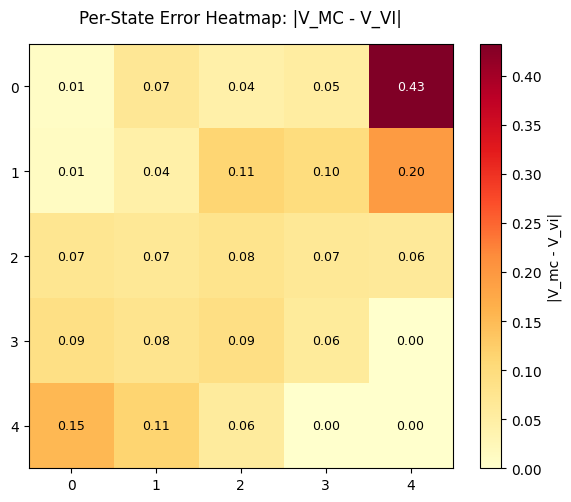

2026-06-12 03:29:03,225 - INFO - Comparison Summary: MAE=0.0824, max_err=0.4323, policy_agree=83.3%


In [57]:
import matplotlib.pyplot as plt
import os
import numpy as np

os.makedirs('images', exist_ok=True)

log_section(logger, "Problem 4: Advanced Comparison (MC vs VI)")

# Metrics
v_mc_arr = np.array(v_mc)
v_std_arr = np.array(v_standard)

v_diff = np.abs(v_mc_arr - v_std_arr)
mae = float(np.mean(v_diff))
max_err = float(np.max(v_diff))

# Policy Agreement
action_symbols = ['↑', '→', '↓', '←']
p_list_mc = [action_symbols[a] if i != 24 else 'G' for i, a in enumerate(policy_mc)]

non_term_states = [s for s in range(25) if s != 24]
matches = sum(1 for s in non_term_states if policy_standard[s] == p_list_mc[s])
pol_agree = matches / len(non_term_states)

#Logger
logger.info("=" * 66)
logger.info("  Off-Policy MC  vs  Standard Value Iteration")
logger.info("=" * 66)
logger.info(f"  {'Metric':<30} {'MC':>15} {'VI':>15}")
logger.info(f"  {'-'*60}")
# num_episodes, iter_standard, time_mc, time_standard
logger.info(f"  {'Episodes / Iterations':<30} {num_episodes:>15,} {iter_standard:>15,}")
logger.info(f"  {'Wall-clock time (s)':<30} {time_mc:>15.5f} {time_standard:>15.5f}")
logger.info(f"  {'Needs env model?':<30} {'No':>15} {'Yes':>15}")
logger.info(f"  {'MAE vs VI ground truth':<30} {mae:>15.4f} {'0.0000':>15}")
logger.info(f"  {'Max |V_mc - V_vi|':<30} {max_err:>15.4f} {'0.0000':>15}")
logger.info(f"  {'Policy agreement with VI':<30} {pol_agree:>14.1%} {'100.0%':>15}")
logger.info("=" * 66)

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
diff_grid = v_diff.reshape(5, 5)

#  YlOrRd 
im = ax.imshow(diff_grid, cmap='YlOrRd', vmin=0)
plt.colorbar(im, ax=ax, label='|V_mc - V_vi|')

for s in range(25):
    r, c = s // 5, s % 5
    text_color = 'white' if diff_grid[r, c] > (max_err * 0.6) else 'black'
    ax.text(c, r, f'{v_diff[s]:.2f}', ha='center', va='center', 
            fontsize=9, color=text_color)

ax.set_title('Per-State Error Heatmap: |V_MC - V_VI|', pad=15)
ax.set_xticks(range(5))
ax.set_yticks(range(5))

# save image
plt.tight_layout()
plt.savefig('images/MC_vs_VI_error.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info(f"Comparison Summary: MAE={mae:.4f}, max_err={max_err:.4f}, policy_agree={pol_agree*100:.1f}%")

### 🔮 Talking Points (Problem 4)

**Talking Point A : Key Reinforcement Learning Feature**
* The key feature here is **Off-policy learning** with **Importance Sampling**. In this method, the agent uses two different policies. The *behavior policy* acts randomly to explore the gridworld. The *target policy* tries to learn the best path. We use the Importance Sampling ratio to fix the difference between the data we collected and the policy we want to learn.

**Talking Point B : Implementation and Testing Challenge**
* A big challenge was understanding and coding the weight variable `W` in the backward loop. If the behavior policy takes an action, but the greedy target policy would *not* take it, the weight `W` becomes exactly zero. When this happens, the loop must stop (`break`). It took me some time to understand why we stop updating the values for the rest of that episode history.

**Talking Point C : Why This Is Reinforcement Learning**
* This is RL because the agent learns from playing the game (episodes) without knowing the environment's rules beforehand. 